In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

### Initialize

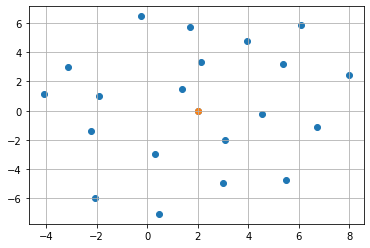

In [6]:
## Parameter Setting

N = 20 # Number of balls
R_cont = 8.3 # Radius of Container
R_ball = 1.0 # Radius of Balls
d = 2.0 # Distance to axis
m = 1 # Mass of Balls
I = 1 # Moment of Inertia of Balls
mubb = 1 # Ball-ball Friction
mubc = 100 # Ball-container Friction

Period = 10 #例
dt = 1e-5 # Time Step
Total_step = int(Period/dt)
T_relax = 20

#error_distance = (d+R_cont)*2*np.pi/Period*dt
error_distance = 0


### Initial Configuration

def initconfig(R_cont,R_ball,d,N,error_distance):
    
    config = np.zeros([N+1,5]) # rx,ry,vx,vy,w    (in lab frame)
    config[N,0] = d   # Initial displacement from origin of the center of the container
    i = 0
    while i<N:
        x = random.uniform(d-R_cont,d+R_cont)
        y = random.uniform(-R_cont,R_cont)
        count = 0
        if (x-d)**2+y**2 <= (R_cont-R_ball-error_distance)**2: #检测有没有碰到圆盘
            if i == 0:  # 第一个球不用管其他球
                config[0,0], config[0,1] = x,y
                i += 1
            else:       # 其他球检测有没有互相碰到
                for k in range(i):    # 其他球逐个检测，没有碰到则k加1
                    if (x-config[k,0])**2+(y-config[k,1])**2 >= (2*R_ball + error_distance)**2:
                        count += 1
                if count == i:     # 如果之前所有k加起来等于该球编号，则没有相互堆叠
                    config[i,0],config[i,1] = x,y
                    i += 1
                    
    return config


### Calculate Average Instantaneous Angular Velocity

def calcwbCOM(res:np.array, time, tspan, nBall):

    N = nBall
    array = np.array;cross = np.cross;norm = np.linalg.norm
    w = 0
    for t in range(time-tspan,time+tspan+1): #关于时间平均

        xCOM = array([sum(res[t,:,0])/N,sum(res[t,:,1])/N])   # Displacement of COM of all balls from lab frame origin
        vCOM = array([sum(res[t,:,2])/N,sum(res[t,:,3])/N])   # Velocity of COM of all balls in lab frame
        
        for i in range(N):
            r = array([res[t,i,0] - xCOM[0],res[t,i,1] - xCOM[1]]) # Displacement of a single ball from center of mass of all balls
            v = array([res[t,i,2] - vCOM[0],res[t,i,3] - vCOM[1]]) # Velocity of a single ball with respect with center of mass of all balls
            w += cross(r,v)/(norm(r))**2/N/(2*tspan+1)

    return w

def calcwbc(res:np.array, time, tspan, nBall):
    
    pass

def calcwCOMc(res:np.array, time, tspan, nBall):
    
    pass

### Initialization Rough Graph

ini = initconfig(R_cont,R_ball,d,N,error_distance)

plt.scatter(ini[:,0],ini[:,1])
plt.scatter(ini[N,0],ini[N,1])
plt.grid()

### Run Simulation

In [7]:
from numpy import double

def RunSim(initconfig:np.array, Total_step, dt_ ,N_ ,R_cont_ ,R_ball_ ,d_ ,m_ ,I_ ,mubb_ ,mubc_ ,error_distance_):

    dt=dt_;N=N_;R_cont=R_cont_;R_ball=R_ball_;d=d_;m=m_;I_=0.4*m*R_ball**2;mubb=mubb_;mubc=mubc_;error_distance=error_distance_
    array = np.array;cross = np.cross;norm = np.linalg.norm; cos = np.cos;sin=np.sin;sqrt=np.sqrt;dot =np.dot;abs=np.abs;sign=np.sign;pi = np.pi
    config = initconfig

    res = np.zeros([Total_step,N+1,5],dtype=double) # Result storage array

    for s in range(Total_step): # Iterate by time steps
       
        config[N,0] = d*cos(s*2*pi/(Period)*dt) # x-displacement from lab frame origin of the container
        config[N,1] = d*sin(s*2*pi/(Period)*dt) # y-displacement from lab frame origin of the container
        uC = array([config[N,1],-config[N,0]])*2*pi*d/Period # velocity vector of container
        
        for i in range(N): # iterate for each ball, one by one

            for k in range(N): # ball-ball collision
                
                if (not k==i) and (config[k,1]-config[i,1])**2 + (config[k,0]-config[i,0])**2 <= (2*R_ball+error_distance)**2:
                        
                    n = array([config[k,0]-config[i,0],config[k,1]-config[i,1]])
                    n /= sqrt((config[k,1]-config[i,1])**2 + (config[k,0]-config[i,0])**2) # unit normal vector pointing k
                    t = array([config[k,1]-config[i,1],config[i,0]-config[k,0]])
                    t /= sqrt((config[k,1]-config[i,1])**2 + (config[k,0]-config[i,0])**2) # unit tangenial vector
                    ui_n = dot(array([config[i,2],config[i,3]]),n)
                    ui_t = dot(array([config[i,2],config[i,3]]),t)
                    uk_n = dot(array([config[k,2],config[k,3]]),n)
                    uk_t = dot(array([config[k,2],config[k,3]]),t)
                    wi = config[i,4]
                    wk = config[k,4]
                    v_r = uk_t - ui_t + R_ball* (wi + wk)

                    vi_n = uk_n
                    vk_n = ui_n

                    J_k = m*mubb*(vk_n-uk_n)
                    J_s = abs(v_r) / (2/m + 2*R_ball**2/I)
                    J = -sign(v_r)*min(J_k,J_s)

                    vi_t = ui_t - J/m
                    vk_t = uk_t + J/m
                    wi += R_ball*J/I
                    wk += R_ball*J/I

                    config[i,2] = dot(array([vi_n,vi_t]),n) #vi_x
                    config[k,2] = dot(array([vk_n,vk_t]),n) #vk_x
                    config[i,3] = dot(array([vi_n,vi_t]),t) #vi_y
                    config[k,3] = dot(array([vk_n,vk_t]),t) #vk_y
                    config[i,4] = wi
                    config[k,4] = wk            

            
            if (config[i,1]-config[N,1])**2 + (config[i,0]-config[N,0])**2 >= (R_cont-R_ball-error_distance)**2: #ball-container collision
                
                n = array([config[N,0]-config[i,0],config[N,1]-config[i,1]])
                n /= sqrt((config[N,1]-config[i,1])**2 + (config[N,0]-config[i,0])**2) # unit normal vector pointing at center of container from ball
                t = array([config[N,1]-config[i,1],config[i,0]-config[N,0]])
                t /= sqrt((config[N,1]-config[i,1])**2 + (config[N,0]-config[i,0])**2) # unit tangential vector
                # r = (R_cont-R_ball)*n
                # config[i,0],config[i,1] = config[N,0]-r[0],config[N,1]-r[1] #修正出圈
                ui_n = dot(array([config[i,2],config[i,3]]),n)
                ui_t = dot(array([config[i,2],config[i,3]]),t)
                uC_n = dot(uC,n)
                uC_t = dot(uC,t)
                wi = config[i,4]
                wC = 0.0  #container not rotating
                v_r = ui_t - uC_t + R_ball* (wi + wC)

                dv = 2*(uC_n - ui_n)          
                J_k = m*mubc*(dv)
                J_s = abs(v_r) / (1/m + R_ball**2/I)
                J = -sign(v_r)*min(J_k,J_s)

                vi_n = ui_n - dv
                vi_t = ui_t + J/m
                wi += R_ball*J/I                            

                config[i,2] = dot(array([vi_n,vi_t]),n)
                config[i,3] = dot(array([vi_n,vi_t]),t)
                config[i,4] = wi
            
            ax = -mubc*9.8*sign(config[i,2]-uC[0]) # Friction in x,y direction
            ay = -mubc*9.8*sign(config[i,3]-uC[1])
                          
            config[i,0] += config[i,2] * dt + 0.5 * ax * dt**2 # Constant Acc 2d motion of balls
            config[i,1] += config[i,3] * dt + 0.5 * ay * dt**2
            config[i,2] += ax * dt # Adjustment of velocity at the end of dt
            config[i,3] += ay * dt
            # No effect of Friction on Angular Velocity while moving
    
        res[s,:,:] = config
    return res

ini = initconfig(R_cont,R_ball,d,N,error_distance)
res = RunSim(ini,Total_step,dt,N,R_cont,R_ball,d,m,I,mubb,mubc,error_distance)

/var/folders/zs/hyfj71ps7dx1pp8qngmvjkxh0000gn/T/ipykernel_9603/3015775924.py:21: RuntimeWarning: overflow encountered in double_scalars
  if (not k==i) and (config[k,1]-config[i,1])**2 + (config[k,0]-config[i,0])**2 <= (2*R_ball+error_distance)**2:
/var/folders/zs/hyfj71ps7dx1pp8qngmvjkxh0000gn/T/ipykernel_9603/3015775924.py:55: RuntimeWarning: overflow encountered in double_scalars
  if (config[i,1]-config[N,1])**2 + (config[i,0]-config[N,0])**2 >= (R_cont-R_ball-error_distance)**2: #ball-container collision
/var/folders/zs/hyfj71ps7dx1pp8qngmvjkxh0000gn/T/ipykernel_9603/3015775924.py:58: RuntimeWarning: overflow encountered in double_scalars
  n /= sqrt((config[N,1]-config[i,1])**2 + (config[N,0]-config[i,0])**2) # unit normal vector pointing at center of container from ball
/var/folders/zs/hyfj71ps7dx1pp8qngmvjkxh0000gn/T/ipykernel_9603/3015775924.py:60: RuntimeWarning: overflow encountered in double_scalars
  t /= sqrt((config[N,1]-config[i,1])**2 + (config[N,0]-config[i,0])**2) #

### 某一时刻的位置

In [1]:
#s = int(100)
# s = int(30380)
print(Total_step)
#s = int(Total_step-1)
s = int(5150)

fig, ax = plt.subplots(figsize=(10,10))
for i in range(N):
    balls = plt.Circle((res[s,i,0],res[s,i,1]),R_ball,color="blue",fill=True)
    ax.add_artist(balls) 
    
container = plt.Circle((res[s,N,0],res[s,N,1]),R_cont,fill=False)
ax.add_artist(container)
# plt.quiver(res[s,:,0],res[s,:,1],res[s,:,2],res[s,:,3])
# plt.quiver(res[s,N,0],res[s,N,1],res[s,N,2],res[s,N,3])
plt.xlim([-10,10])
plt.ylim([-10,10])
plt.grid()

NameError: name 'Total_step' is not defined

### Calculate Specific w

In [9]:
t = 50000
tspan = 10
print(calcw(res,t,tspan,N))

NameError: name 'calcw' is not defined

In [ ]:
s = Total_step-1
plt.scatter(res[s,:,0],res[s,:,1])
plt.scatter(res[s,N,0],res[s,N,1])
plt.xlim([-20,20])
plt.ylim([-20,20])
plt.grid()

### Calculate w Evolution

In [ ]:
tspan = 10

w_evol = np.zeros([Total_step-2*tspan,2])
for w in range(tspan, Total_step-tspan+1,10000):
    w_evol[w-tspan,0] = w
    w_evol[w-tspan,1] = calcw(res,w,tspan,N)

plt.figure()
plt.plot(w_evol[:,0],w_evol[:,0],'-g')
plt.grid()
    


In [ ]:
stone = plt.Circle((0,0),1)
fig, ax = plt.subplots()
ax.add_artist(stone)

Text(0, 0.5, 'Ωbc(deg/s)')

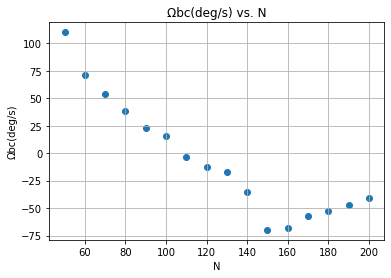

In [5]:
plt.figure()
N = [50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200]
w = [102.018+8	,78.39-7.2	,47.972+6	,32.172+6.3	,14.888+7.7	,8.24+7	,2.55-6.3	,-5.258-7.3	,-25.364+8.5	,-44.578+9.0	,-60.676-9.2	,-64.586-3.2	,-57.756+0.4	,-49.478-3.5,	-43.84-3.3	,-36.298-4.9]
plt.scatter(N,w)
plt.grid()
plt.title('Ωbc(deg/s) vs. N')
plt.xlabel("N")
plt.ylabel("Ωbc(deg/s)")

(array([45., 50., 55., 60., 65., 70., 75., 80.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

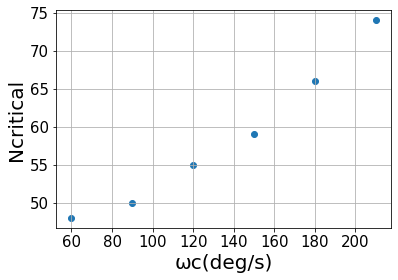

In [18]:
plt.figure()
wc = [60.00,90.00,120.00,150.00,180.00,210.00]
Nctheo = [48,50,55,59,66,74]
plt.scatter(wc,Nctheo)
plt.grid()
plt.xlabel("ωc(deg/s)",fontsize = 20)
plt.ylabel("Ncritical",fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)


(array([15., 16., 17., 18., 19., 20., 21., 22.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

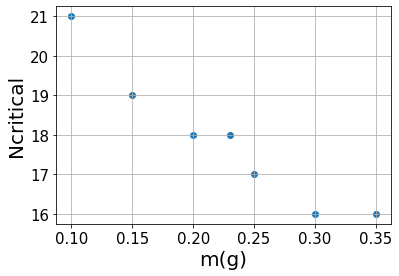

In [16]:
plt.figure()
m2 = [0.10,0.15,0.2,0.23,0.25,0.30,0.35]
Nctheo = [21,19,18,18,17,16,16]
plt.scatter(m2,Nctheo)
plt.grid()
plt.xlabel("m(g)",fontsize = 20)
plt.ylabel("Ncritical",fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([ 20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

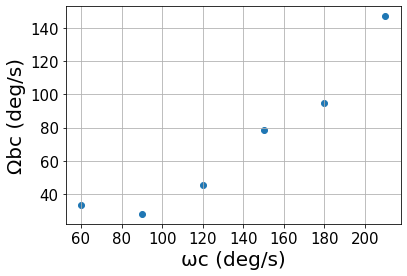

In [19]:
plt.figure()
wc = [60,90,120,150,180,210]
Nctheo = [27.123411+6.4,32.12341-4.2,40.40621+4.8,75.123411+3.3,100.12344-5.2,139.736+7.4]
plt.scatter(wc,Nctheo)
plt.grid()
plt.xlabel("ωc (deg/s)",fontsize = 20)
plt.ylabel("Ωbc (deg/s)",fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([49., 50., 51., 52., 53., 54., 55., 56., 57.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

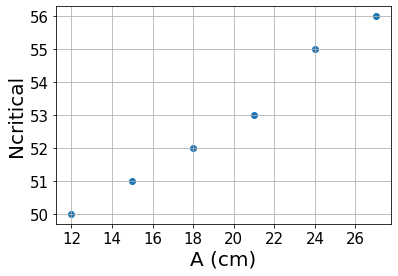

In [20]:
plt.figure()
A = [12,15,18,21,24,27]
plt.grid()
Nctheo = [50,51,52,53,55,56]
plt.scatter(A,Nctheo)
plt.xlabel('A (cm)',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([35., 40., 45., 50., 55., 60., 65., 70., 75., 80.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

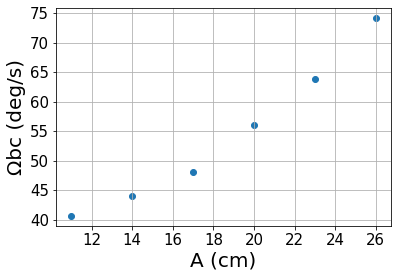

In [23]:
plt.figure()
A = [12-1,15-1,18-1,21-1,24-1,27-1]
wtheo = [40.6745,43.987762,48.1,55.9777,63.897,74.12341]
plt.grid()

plt.scatter(A,wtheo)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xlabel('A (cm)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([59., 60., 61., 62., 63., 64., 65., 66., 67., 68.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

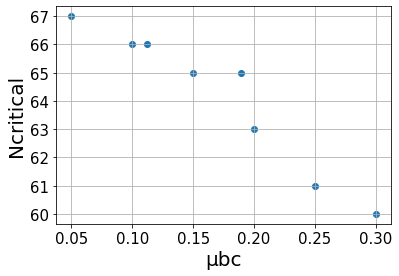

In [24]:
plt.figure()
mubc2 = [0.05,0.10,0.11210,0.15,0.18896,0.20,0.25,0.30]
Nctheo = [67,66,66,65,65,63,61,60]
plt.grid()

plt.scatter(mubc2,Nctheo)
plt.xlabel('μbc',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([59., 60., 61., 62., 63., 64., 65., 66.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

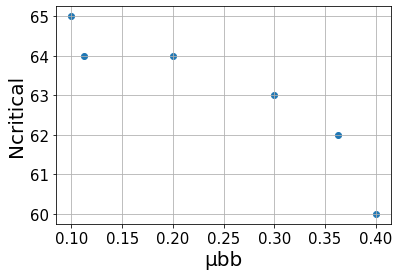

In [26]:
plt.figure()

mubb2 = [0.1,0.11210,0.2,0.3,0.36228,0.4]
Nctheo = [65,64,64,63,62,60]
plt.grid()

plt.scatter(mubb2,Nctheo)
plt.xlabel('μbb',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([-30., -20., -10.,   0.,  10.,  20.,  30.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

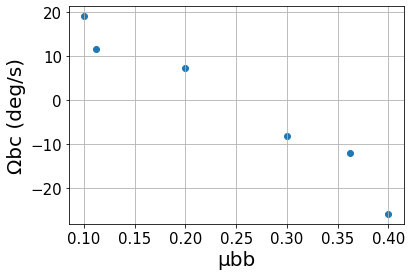

In [28]:
plt.figure()

mubb2 = [0.1,0.11210,0.2,0.3,0.36228,0.4]
wtheo = [19.121,16.88823-5.231,7.213412,-8.21341,-18.123481+6.11,-25.99]
plt.grid()

plt.scatter(mubb2,wtheo)
plt.xlabel('μbb',fontsize = 20)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([10., 15., 20., 25., 30., 35., 40., 45., 50., 55.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

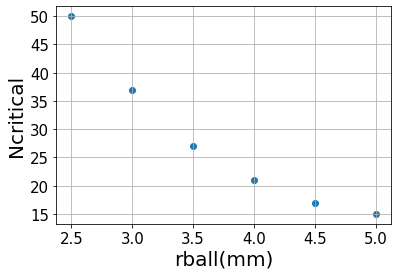

In [29]:
plt.figure()

r = [5/2,6/2,7/2,8/2,9/2,10/2]

Nctheo = [50,37,27,21,17,15]
plt.grid()

plt.scatter(r,Nctheo)
plt.xlabel('rball(mm)',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([30., 40., 50., 60., 70., 80., 90.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

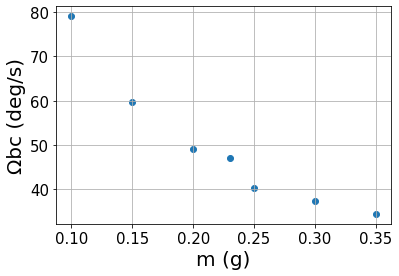

In [10]:
plt.figure()

m2 = [0.10,0.15,0.2,0.23,0.25,0.30,0.35]

wtheo = [79.1,52.81232+7,49.11,43.11334+4,40.2,37.222,34.41]
plt.grid()

plt.scatter(m2,wtheo)
plt.xlabel('m (g)',fontsize=20)
plt.ylabel('Ωbc (deg/s)',fontsize=20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)



(array([ 0., 10., 20., 30., 40., 50., 60., 70., 80.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

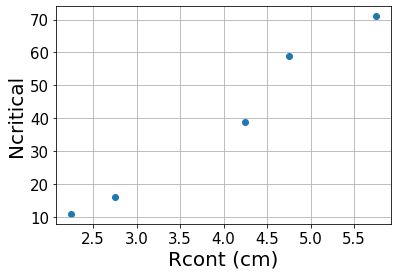

In [30]:
plt.figure()
R2 = [4.5/2,5.5/2,8.5/2,9.5/2,11.5/2]
Nctheo = [11,16,39,59,71]
plt.grid()


plt.scatter(R2,Nctheo)
plt.xlabel('Rcont (cm)',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([-30., -20., -10.,   0.,  10.,  20.,  30.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

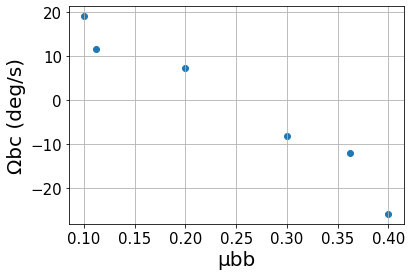

In [31]:
plt.figure()
mubb2 = [0.1,0.11210,0.2,0.3,0.36228,0.4]
wtheo = [19.121,16.88823-5.231,7.213412,-8.21341,-18.123481+6.11,-25.99]
plt.grid()

plt.scatter(mubb2,wtheo)
plt.xlabel('μbb',fontsize = 20)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([-40., -20.,   0.,  20.,  40.,  60.,  80., 100.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

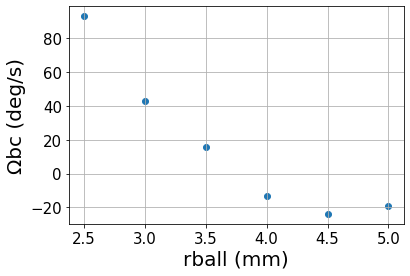

In [32]:
plt.figure()

r = [5/2,6/2,7/2,8/2,9/2,10/2]

wtheo = [93.121,43.12,15.94,-13.512,-23.9,-19.2]
plt.grid()

plt.scatter(r,wtheo)
plt.xlabel('rball (mm)',fontsize = 20)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([-125., -100.,  -75.,  -50.,  -25.,    0.,   25.,   50.,   75.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

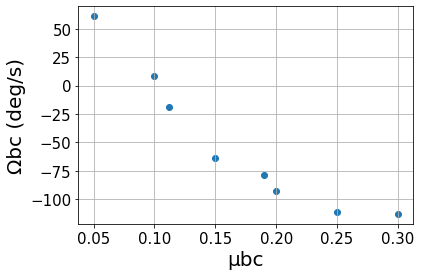

In [33]:
plt.figure()

mubc = [0.05,0.10,0.112,0.15,0.190,0.20,0.25,0.30]

wtheo = [61,8,-19,-64,-79,-93,-111,-113]
plt.grid()

plt.scatter(mubc,wtheo)
plt.xlabel('μbc',fontsize = 20)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([10., 15., 20., 25., 30., 35., 40., 45., 50., 55.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

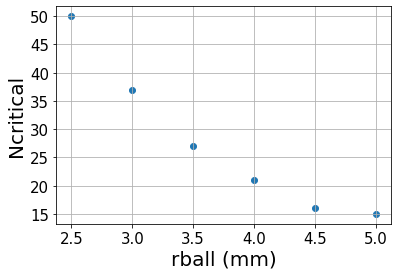

In [34]:
plt.figure()

rball = [2.5,3.0,3.5,4.0,4.5,5.0]

Nc = [50,37,27,21,16,15]
plt.grid()

plt.scatter(rball,Nc)
plt.xlabel('rball (mm)',fontsize = 20)
plt.ylabel('Ncritical',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

(array([-40., -20.,   0.,  20.,  40.,  60.,  80.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

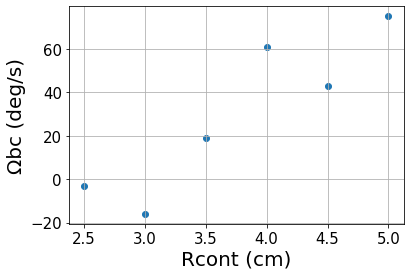

In [35]:
plt.figure()
R2 = [2.5,3.0,3.5,4,4.5,5]
wtheo = [-3,-16,19,61,43,75]
plt.grid()

plt.scatter(R2,wtheo)
plt.xlabel('Rcont (cm)',fontsize = 20)
plt.ylabel('Ωbc (deg/s)',fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)